**This notebook explores the Dirty Cafe Sales dataset which contains 10,000 cafe transactions. 
The data includes missing values and inconsistent entries to reflect real world scenarios.**


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

**1. Load Data**

In [2]:
df = pd.read_csv("dirty_cafe_sales.csv")
# Handle numeric columns
df['Quantity'] = pd.to_numeric(df['Quantity'], errors='coerce')
df['Price Per Unit'] = pd.to_numeric(df['Price Per Unit'], errors='coerce')
df['Total Spent'] = pd.to_numeric(df['Total Spent'], errors='coerce')

**2.Basic Overview**

In [3]:
df.shape

(10000, 8)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Transaction ID    10000 non-null  object 
 1   Item              9667 non-null   object 
 2   Quantity          9521 non-null   float64
 3   Price Per Unit    9467 non-null   float64
 4   Total Spent       9498 non-null   float64
 5   Payment Method    7421 non-null   object 
 6   Location          6735 non-null   object 
 7   Transaction Date  9841 non-null   object 
dtypes: float64(3), object(5)
memory usage: 625.1+ KB


In [5]:
df.head()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2.0,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4.0,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4.0,1.0,NaN,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2.0,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2.0,2.0,4.0,Digital Wallet,In-store,2023-06-11


In [6]:
df.tail()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
9995,TXN_7672686,Coffee,2.0,2.0,4.0,NaN,UNKNOWN,2023-08-30
9996,TXN_9659401,NaN,3.0,NaN,3.0,Digital Wallet,NaN,2023-06-02
9997,TXN_5255387,Coffee,4.0,2.0,8.0,Digital Wallet,NaN,2023-03-02
9998,TXN_7695629,Cookie,3.0,NaN,3.0,Digital Wallet,NaN,2023-12-02
9999,TXN_6170729,Sandwich,3.0,4.0,12.0,Cash,In-store,2023-11-07


**3. Check Missing Values**

In [7]:
df.isna().sum()

Transaction ID         0
Item                 333
Quantity             479
Price Per Unit       533
Total Spent          502
Payment Method      2579
Location            3265
Transaction Date     159
dtype: int64

**4.Check Duplicates**

In [8]:
df.duplicated().sum()

np.int64(0)

**5.Inspect Unique Values**

In [9]:
for col in df.columns:
    print(f"\n{col}")
    print(df[col].unique()[:10])


Transaction ID
['TXN_1961373' 'TXN_4977031' 'TXN_4271903' 'TXN_7034554' 'TXN_3160411'
 'TXN_2602893' 'TXN_4433211' 'TXN_6699534' 'TXN_4717867' 'TXN_2064365']

Item
['Coffee' 'Cake' 'Cookie' 'Salad' 'Smoothie' 'UNKNOWN' 'Sandwich' nan
 'ERROR' 'Juice']

Quantity
[ 2.  4.  5.  3.  1. nan]

Price Per Unit
[2.  3.  1.  5.  4.  1.5 nan]

Total Spent
[ 4. 12. nan 10. 20.  9. 16. 15. 25.  8.]

Payment Method
['Credit Card' 'Cash' 'UNKNOWN' 'Digital Wallet' 'ERROR' nan]

Location
['Takeaway' 'In-store' 'UNKNOWN' nan 'ERROR']

Transaction Date
['2023-09-08' '2023-05-16' '2023-07-19' '2023-04-27' '2023-06-11'
 '2023-03-31' '2023-10-06' '2023-10-28' '2023-07-28' '2023-12-31']


**6.No. of rows and columns**

In [10]:
print("Shape (rows, columns):", df.shape, "\n")

print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Shape (rows, columns): (10000, 8) 

Number of rows: 10000
Number of columns: 8


### 7.Descriptive summary Statistics

In [11]:
df.describe(include='all')

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
count,10000,9667,9521.000000,9467.000000,9498.000000,7421,6735,9841
unique,10000,10,NaN,NaN,NaN,5,4,367
top,TXN_6170729,Juice,NaN,NaN,NaN,Digital Wallet,Takeaway,UNKNOWN
freq,1,1171,NaN,NaN,NaN,2291,3022,159
mean,NaN,NaN,3.028463,2.949984,8.924352,NaN,NaN,NaN
std,NaN,NaN,1.419007,1.278450,6.009919,NaN,NaN,NaN
min,NaN,NaN,1.000000,1.000000,1.000000,NaN,NaN,NaN
25%,NaN,NaN,2.000000,2.000000,4.000000,NaN,NaN,NaN
50%,NaN,NaN,3.000000,3.000000,8.000000,NaN,NaN,NaN
75%,NaN,NaN,4.000000,4.000000,12.000000,NaN,NaN,NaN


**8.visual analysis**

**Univariate:**

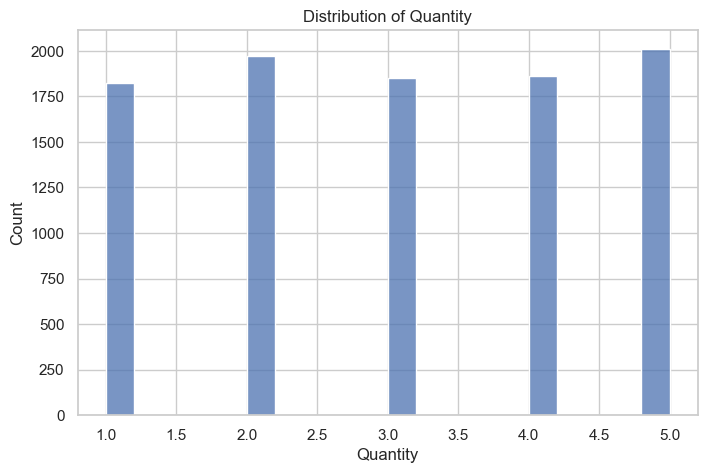

In [12]:
plt.figure(figsize=(8,5))
sns.histplot(df['Quantity'], bins=20)
plt.title("Distribution of Quantity")
plt.show()

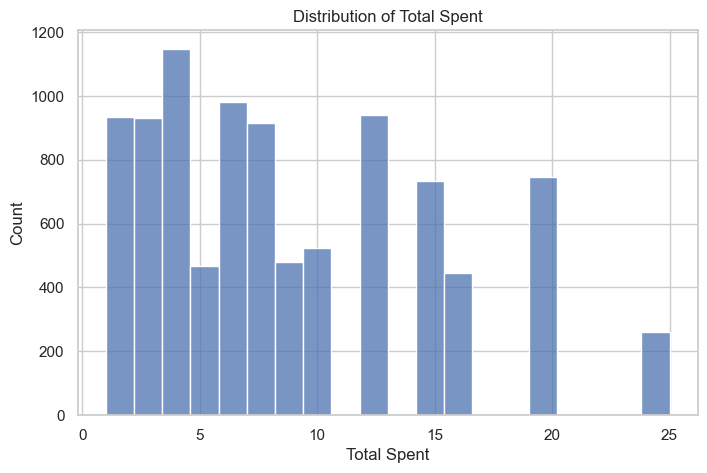

In [13]:
plt.figure(figsize=(8,5))
sns.histplot(df['Total Spent'], bins=20)
plt.title("Distribution of Total Spent")
plt.show()

**Bivariate:**

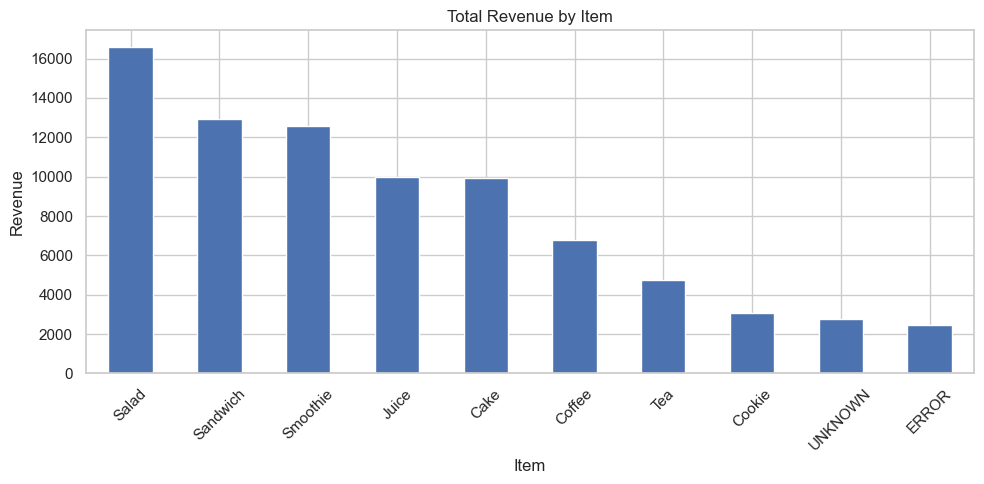

Item
Salad       16605.0
Sandwich    12956.0
Smoothie    12556.0
Juice        9984.0
Cake         9933.0
Coffee       6784.0
Tea          4735.5
Cookie       3070.0
UNKNOWN      2757.5
ERROR        2453.5
Name: Total Spent, dtype: float64


In [14]:
item_revenue = df.groupby('Item')['Total Spent'].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 5))
item_revenue.plot(kind='bar')
plt.title("Total Revenue by Item")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print(item_revenue)

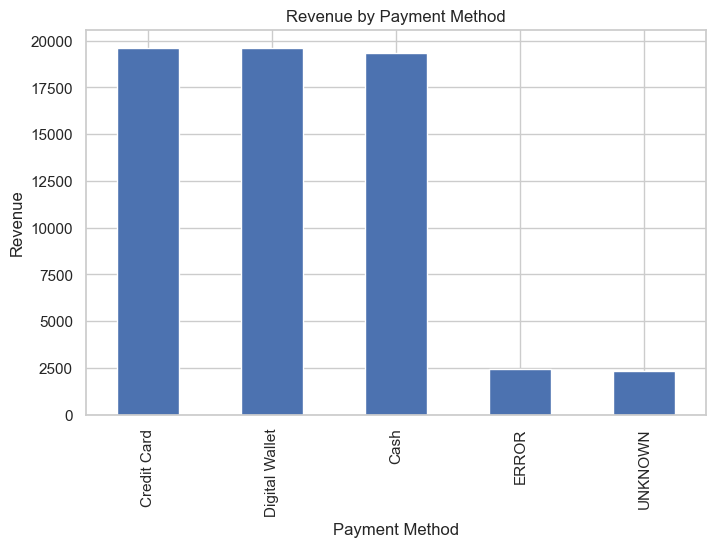

In [15]:
payment_revenue = df.groupby('Payment Method')['Total Spent'].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
payment_revenue.plot(kind='bar')
plt.title("Revenue by Payment Method")
plt.ylabel("Revenue")
plt.show()

**Price Per Unit vs Total Spent Relationship**

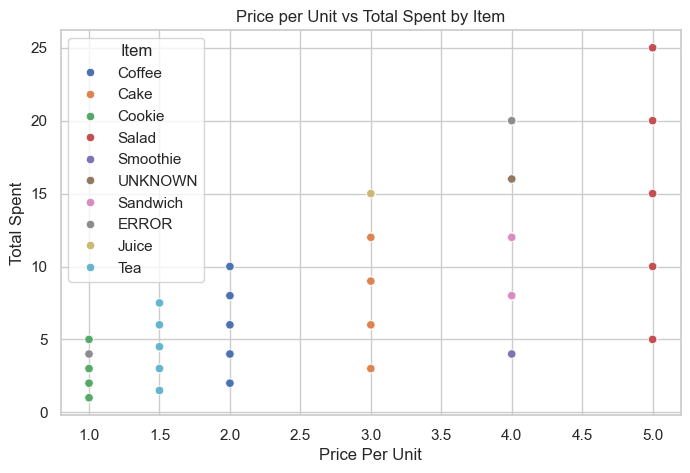

In [16]:
plt.figure(figsize=(8,5))
sns.scatterplot(
    x='Price Per Unit',
    y='Total Spent',
    hue='Item',
    data=df
)
plt.title("Price per Unit vs Total Spent by Item")
plt.show()

The scatter plot shows that higher price per unit generally leads to higher total spending.
Different items form visible clusters, indicating that product type plays an important role in total transaction value.
This confirms that pricing structure significantly influences overall sales performance.

**Correlation Matrix**

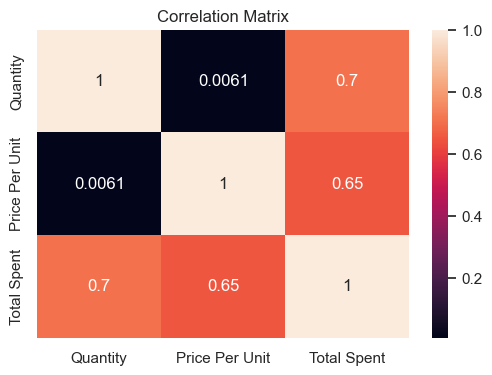

In [17]:
plt.figure(figsize=(6,4))
sns.heatmap(df[['Quantity','Price Per Unit','Total Spent']].corr(), annot=True)
plt.title("Correlation Matrix")
plt.show()

The correlation matrix shows a strong positive relationship between Quantity and Total Spent (0.7),
which is expected since total spending increases with higher quantity.
Price Per Unit also shows a moderate correlation with Total Spent (0.65).
There is almost no relationship between Quantity and Price Per Unit.

**Time Analysis:**

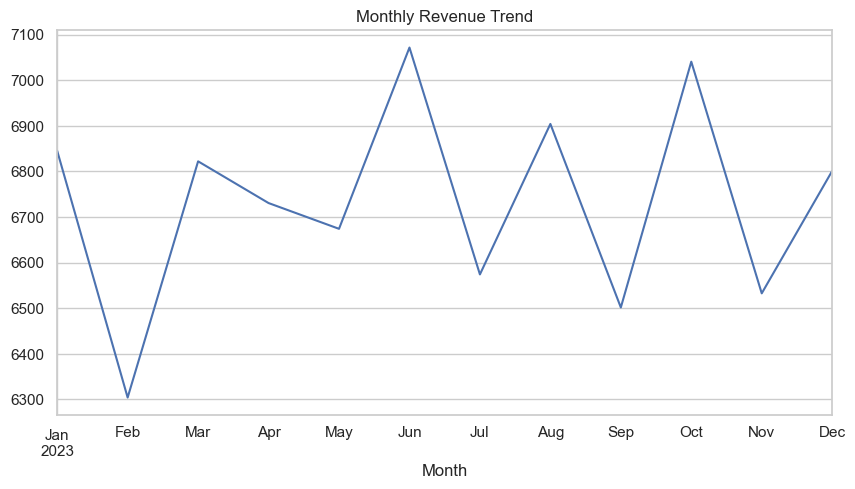

In [18]:
df['Transaction Date'] = pd.to_datetime(df['Transaction Date'], errors='coerce')
df['Month'] = df['Transaction Date'].dt.to_period('M')

monthly_sales = df.groupby('Month')['Total Spent'].sum()

monthly_sales.plot(figsize=(10,5))
plt.title("Monthly Revenue Trend")
plt.show()

## Summary & Key Insights

- **Data Quality:** Dataset contains ERROR/UNKNOWN entries and NaN values — detected and reported for future preprocessing
- **Distributions:** Quantity is roughly uniform (1–5). Total Spent is right-skewed
- **Top Items:** Salad, Sandwich, and Smoothie generate the most revenue
- **Correlations:** Strong (0.7) between Quantity & Total Spent; Moderate (0.65) between Price Per Unit & Total Spent
- **Monthly Trend:** Revenue is fairly stable throughout 2023 with moderate fluctuations